# Niche Query on CCF Dataset


Experiment setup:
- Niche: k-hop neighboring cells across brain sections;
- Positive pairs: RM-ideal.

## Load Data

In [1]:

import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## QueST Embedding

In [2]:
# load data
import numpy as np
import pandas as pd
import torch
import os
import scanpy as sc


def load_emb(adata_folder, emb_folder, emb_key, suffix='pt', update_anndata=True):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)
        if embedding_key in adata.obsm:
            print(f"[SKIP] embedding exists for {fname}")
            continue

        emb_path = os.path.join(emb_folder, f"{stem}.{suffix}")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        if suffix == 'csv':
            emb = pd.read_csv(emb_path, index_col=0).values.astype(np.float64)
        elif suffix == 'pt':
            emb_tensor = torch.load(emb_path, map_location="cpu")
            emb = emb_tensor.detach().cpu().numpy()
        else:
            print(f"[SKIP] not supported suffix {fname}")
            continue

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/notebook/ccf/data/benchmark_samples/20260414_235933'
emb_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419'
embedding_key = 'X_quest_emb'
adata_list = load_emb(adata_folder, emb_folder, emb_key=embedding_key, suffix='pt')

[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/C57BL6J-638850.28.pt
[DONE] C57BL6J-638850.28
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/C57BL6J-638850.29.pt
[DONE] C57BL6J-638850.29
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/C57BL6J-638850.30.pt
[DONE] C57BL6J-638850.30
[SKIP] No embedding for C57BL6J-638850.31.h5ad
[SKIP] No embedding for Zhuang-ABCA-1.096.h5ad
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/Zhuang-ABCA-1.097.pt
[DONE] Zhuang-ABCA-1.097
[LOAD] /Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_single_parcellation_0419/Zhuang-ABCA-1.098.pt
[DONE] Zhuang-ABCA-1.098
[

In [3]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery
import os

# step 1: create db
zhuang_abca_1_folder = 'notebook/ccf/data/zhuang-abca-1/'
zhuang_abca_2_folder = 'notebook/ccf/data/zhuang-abca-2/'
zhuang_abca_3_folder = 'notebook/ccf/data/zhuang-abca-3/'
zeng_mwb_folder = 'notebook/ccf/data/zeng-mwb/'
sample_data_folder = 'notebook/ccf/data/benchmark_samples/20260414_235933'

target_sample_ids = [
    'Zhuang-ABCA-1.098', 'Zhuang-ABCA-1.099', 'Zhuang-ABCA-1.097', #'Zhuang-ABCA-1.096',
    #'Zhuang-ABCA-2.046', 'Zhuang-ABCA-2.047', 'Zhuang-ABCA-2.048', #'Zhuang-ABCA-2.050',
    #'Zhuang-ABCA-3.001', 'Zhuang-ABCA-3.002', 'Zhuang-ABCA-3.004', #'Zhuang-ABCA-3.005',
    'C57BL6J-638850.28', 'C57BL6J-638850.29', 'C57BL6J-638850.30', #'C57BL6J-638850.31'
]

db = Database(target_sample_ids)

db.construct(
    adata_path=[
        sample_data_folder + '/' + sample_id + '.h5ad'
        for sample_id in target_sample_ids
    ],
    cell_metadata_path=[
        zhuang_abca_1_folder + 'cell_metadata.csv',
        zhuang_abca_2_folder + 'cell_metadata.csv',
        zhuang_abca_3_folder + 'cell_metadata.csv',
        zeng_mwb_folder + 'cell_metadata.csv',
    ],
    ccf_coordinates_path=[
        zhuang_abca_1_folder + 'ccf_coordinates.csv',
        zhuang_abca_2_folder + 'ccf_coordinates.csv',
        zhuang_abca_3_folder + 'ccf_coordinates.csv',
        zeng_mwb_folder + 'ccf_coordinates.csv',
    ],
    feature_name=embedding_key,
    parcellation_path='notebook/ccf/data/parcellation/structure.json'
)

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Loading CCF coordinates...
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunksize=_METADATA_CSV_CHUNKSIZE):
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunk

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:225: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'sample_id' as categorical


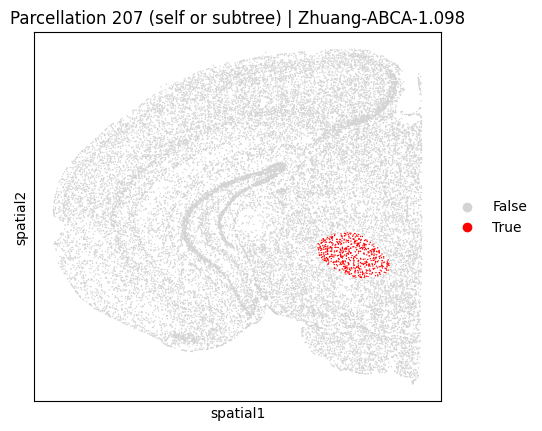

In [4]:
target_parcellation = 207
query_niche_sample_id = 'Zhuang-ABCA-1.098'

db.get_sample(query_niche_sample_id).visualize_parcellation_cells(
    target_parcellation_index=target_parcellation,
    # print_metadata=True,
    spot_size=0.02,
    # metadata_txt_path=f'notebook/ccf/data/benchmark_samples/center_cells/{query_niche_sample_id}_parcellation_207.txt'
)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.098 slice.
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.098')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:249: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Niche cells by parcellation (n_total=100):
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=100


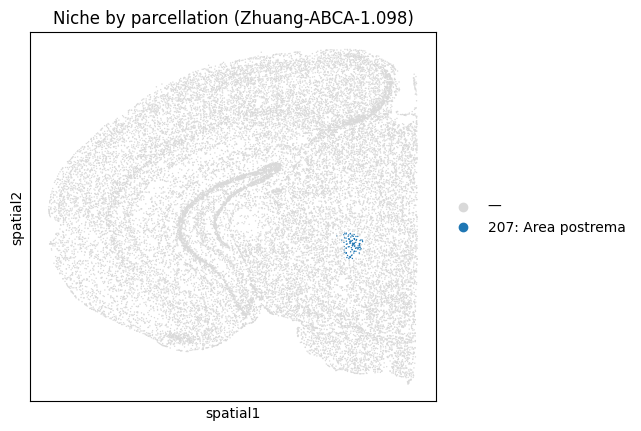

In [5]:
# step 2: construct niche to query;

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='267504471830606554974249492302877563377', sample_id=query_niche_sample_id, \
    k=8, cell_limit=100, parcellation_index=target_parcellation)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr

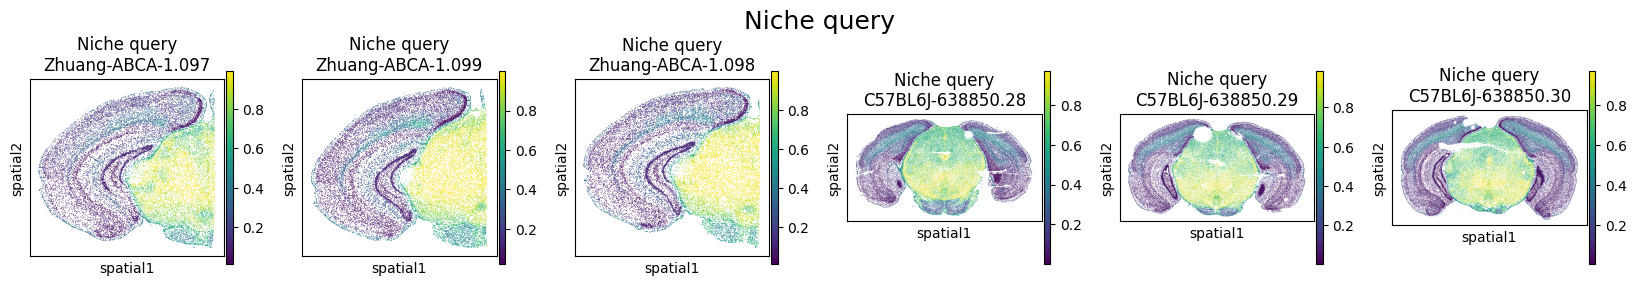

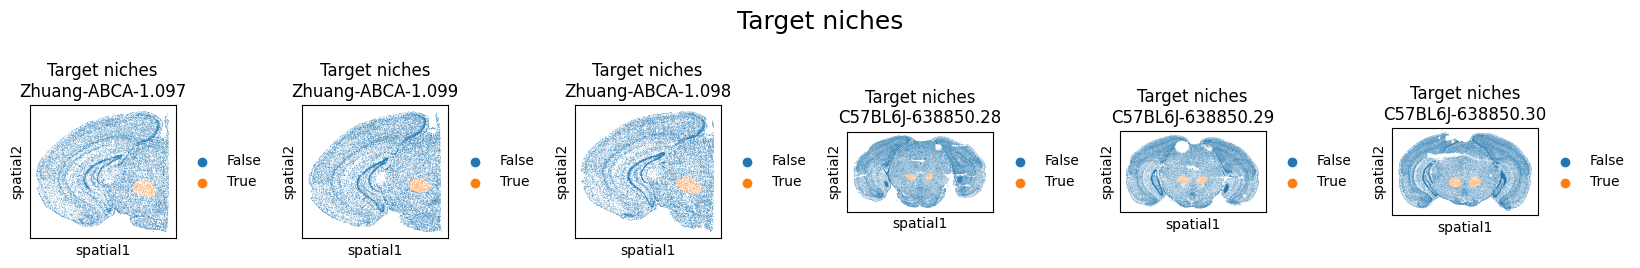

In [6]:
# step 3: run niche query on given samples
import matplotlib.pyplot as plt
import scanpy as sc

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples, show_target_niches=True)

In [7]:
# step 4: classification report
niche_query.niche_query_quantitive_metrics(search_samples=query_samples, \
    result_txt_path='notebook/ccf/data/benchmark_samples/20260414_235933/quantitive_metrics/quest.txt')

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr

[{'sample_id': 'Zhuang-ABCA-1.097',
  'auprc': 0.5219132598801675,
  'pcc': 0.22456510894738774,
  'avg_ncjs': 0.8704278059480072,
  'avg_bio': 0.24158830283764102,
  'avg_batch': nan},
 {'sample_id': 'Zhuang-ABCA-1.099',
  'auprc': 0.21826659982054614,
  'pcc': 0.20097897621169458,
  'avg_ncjs': 0.8803844991153121,
  'avg_bio': 0.25842729229593137,
  'avg_batch': nan},
 {'sample_id': 'Zhuang-ABCA-1.098',
  'auprc': 0.47544311381403404,
  'pcc': 0.23069821659415268,
  'avg_ncjs': 0.8709185003387094,
  'avg_bio': 0.2394661958113898,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.28',
  'auprc': 0.052199713448893875,
  'pcc': 0.13628290327020093,
  'avg_ncjs': 0.896629468996962,
  'avg_bio': 0.21710751376306006,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.29',
  'auprc': 0.10338850235720003,
  'pcc': 0.1921372154235078,
  'avg_ncjs': 0.8934978152546476,
  'avg_bio': 0.2388002326685934,
  'avg_batch': nan},
 {'sample_id': 'C57BL6J-638850.30',
  'auprc': 0.4481754402333902,
  

## Gene Expressions

In [2]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery

# step 1: create db
zhuang_abca_1_folder = 'notebook/ccf/data/zhuang-abca-1/'
zhuang_abca_2_folder = 'notebook/ccf/data/zhuang-abca-2/'
zhuang_abca_3_folder = 'notebook/ccf/data/zhuang-abca-3/'
zeng_mwb_folder = 'notebook/ccf/data/zeng-mwb/'
sample_data_folder = 'notebook/ccf/data/benchmark_samples/20260414_235933'

# target_sample_ids = [
#     'Zhuang-ABCA-1.098', 'Zhuang-ABCA-1.099', 'Zhuang-ABCA-1.097', #'Zhuang-ABCA-1.096',
#     #'Zhuang-ABCA-2.046', 'Zhuang-ABCA-2.047', 'Zhuang-ABCA-2.048', #'Zhuang-ABCA-2.050',
#     #'Zhuang-ABCA-3.001', 'Zhuang-ABCA-3.002', 'Zhuang-ABCA-3.004', #'Zhuang-ABCA-3.005',
#     'C57BL6J-638850.28', 'C57BL6J-638850.29', 'C57BL6J-638850.30', #'C57BL6J-638850.31'
# ]
target_sample_ids = [
    'Zhuang-ABCA-1.098'
]
rm_ideal_output_key = "rm_ideal_score"

db = Database(target_sample_ids)

db.construct(
    adata_path=[
        sample_data_folder + '/' + sample_id + '.h5ad'
        for sample_id in target_sample_ids
    ],
    cell_metadata_path=[
        zhuang_abca_1_folder + 'cell_metadata.csv',
        zhuang_abca_2_folder + 'cell_metadata.csv',
        zhuang_abca_3_folder + 'cell_metadata.csv',
        zeng_mwb_folder + 'cell_metadata.csv',
    ],
    ccf_coordinates_path=[
        zhuang_abca_1_folder + 'ccf_coordinates.csv',
        zhuang_abca_2_folder + 'ccf_coordinates.csv',
        zhuang_abca_3_folder + 'ccf_coordinates.csv',
        zeng_mwb_folder + 'ccf_coordinates.csv',
    ],
    feature_name='gene_expression',
    parcellation_path='notebook/ccf/data/parcellation/structure.json',
    rm_ideal_output_key=rm_ideal_output_key
)


/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Loading CCF coordinates...
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:373: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunksize=_METADATA_CSV_CHUNKSIZE):
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:373: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunk

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.098 slice.
INFO:src.NicheQueryPrototype.niche:Wrote niche membership to adata.obsm['niche_207_123'] (n_in_niche=100, n_obs=26487).
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.098')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:316: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'sample_id' as categorical


Niche cells by parcellation (n_total=100):
  parcellation_index=123  parcellation_name='Koelliker-Fuse subnucleus'  n_cells=60
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=40


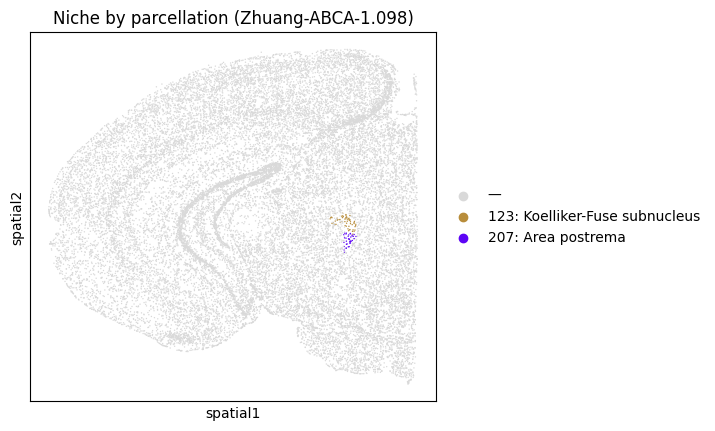

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:338: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


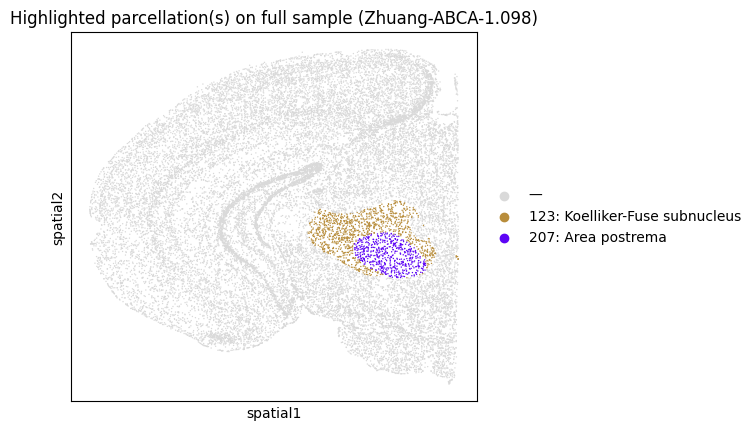

In [3]:
# step 2: construct niche to query;
query_niche_sample_id = 'Zhuang-ABCA-1.098'

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='337502760026487302083958961400454036056', sample_id=query_niche_sample_id, \
    k=10, cell_limit=100, parcellation_index=[207,123], niche_name='niche_207_123')
niche_to_query.visualize(db)

Sample: Zhuang-ABCA-1.098
Cells in parcellation 207: 583
Spatially adjacent parcellations (n=3):
  123: Koelliker-Fuse subnucleus  (cell-cell contacts with 207: 162)
  303: Basolateral amygdalar nucleus, anterior part  (cell-cell contacts with 207: 22)
  739: Anterior cingulate area, layer 5  (cell-cell contacts with 207: 20)


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_93421/844123127.py:89: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


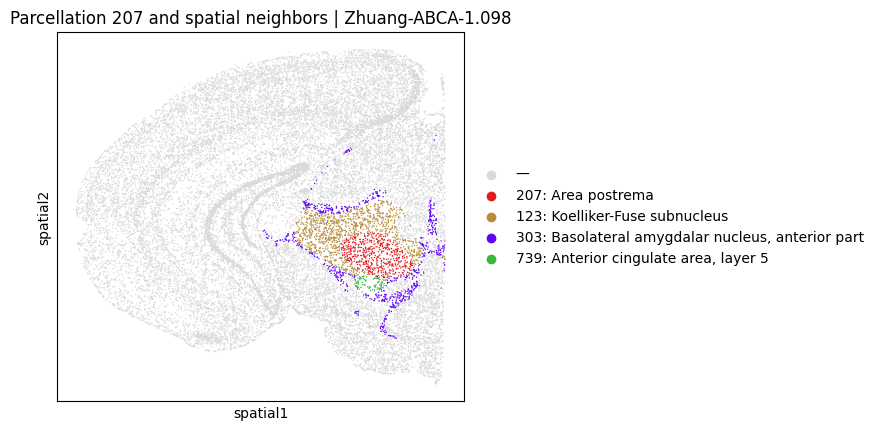

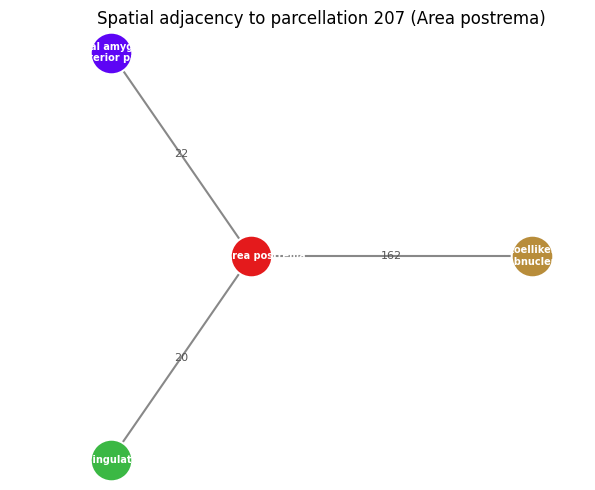

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

from src.NicheQueryPrototype.niche import _distinct_category_hexes
from src.NicheQueryPrototype.rm_ideal import RmIdeal

# --- config ---
target_parcellation = 207
query_niche_sample_id = "Zhuang-ABCA-1.098"
graph_mode = "delaunay"  # "delaunay" | "knn"
knn_k = 3
spot_size = 0.02

def _parcel_name(db, pidx: int) -> str:
    info = db.parcellation_tree.get(pidx, {})
    return (info.get("name") or "").strip() or f"parcellation {pidx}"


def _parcel_label(db, pidx: int) -> str:
    name = _parcel_name(db, pidx)
    return f"{pidx}: {name}" if name else str(pidx)


# --- sample & spatial graph ---
sample = db.get_sample(query_niche_sample_id)
cells = sample.cells
n = len(cells)
coords = np.array([[c.x, c.y] for c in cells], dtype=float)
parc = np.array([c.parcellation_index for c in cells], dtype=int)
cell_ids = [str(c.id) for c in cells]

rm = RmIdeal(graph_mode=graph_mode, knn_k=knn_k)
adj = rm._build_graph(coords, n)

# cells assigned exactly to 207
idx_target = np.where(parc == target_parcellation)[0]

# parcellations that touch 207 across the spatial graph
adjacent_parcels: set[int] = set()
parcel_edge_counts: dict[tuple[int, int], int] = {}

for i in idx_target:
    for j in adj[i]:
        pj = int(parc[j])
        if pj == target_parcellation:
            continue
        adjacent_parcels.add(pj)
        key = tuple(sorted((target_parcellation, pj)))
        parcel_edge_counts[key] = parcel_edge_counts.get(key, 0) + 1

highlight = {target_parcellation} | adjacent_parcels
highlight_sorted = sorted(highlight)

print(f"Sample: {query_niche_sample_id}")
print(f"Cells in parcellation {target_parcellation}: {len(idx_target)}")
print(f"Spatially adjacent parcellations (n={len(adjacent_parcels)}):")
for pidx in sorted(adjacent_parcels):
    n_contacts = parcel_edge_counts.get(
        tuple(sorted((target_parcellation, pidx))), 0
    )
    print(f"  {_parcel_label(db, pidx)}  (cell-cell contacts with 207: {n_contacts})")

# --- spatial highlight (scanpy) ---
pidx_to_label = {p: _parcel_label(db, p) for p in highlight_sorted}
id_to_cell = {str(c.id): c for c in cells}

labels = []
for oid in sample.adata.obs_names:
    c = id_to_cell.get(str(oid))
    if c is None or c.parcellation_index not in highlight:
        labels.append("—")
    elif c.parcellation_index == target_parcellation:
        labels.append(pidx_to_label[target_parcellation])
    else:
        labels.append(pidx_to_label[c.parcellation_index])

# 207 first in legend, then neighbors
neighbor_sorted = sorted(adjacent_parcels)
categories = ["—", pidx_to_label[target_parcellation]] + [
    pidx_to_label[p] for p in neighbor_sorted
]
sample.adata.obs["adjacent_to_207"] = pd.Categorical(labels, categories=categories)

n_colors = 1 + len(neighbor_sorted)
palette = ["#d9d9d9", "#e41a1c"] + _distinct_category_hexes(len(neighbor_sorted))

sc.pl.spatial(
    sample.adata,
    color="adjacent_to_207",
    palette=palette,
    spot_size=spot_size,
    title=f"Parcellation 207 and spatial neighbors | {sample.id}",
)

# --- parcellation adjacency graph (207 at center) ---
fig, ax = plt.subplots(figsize=(max(6, len(neighbor_sorted) * 0.9), 5))
ax.set_title(
    f"Spatial adjacency to parcellation {target_parcellation} "
    f"({_parcel_name(db, target_parcellation)})"
)
ax.axis("off")

if not neighbor_sorted:
    ax.text(0.5, 0.5, "No adjacent parcellations found.", ha="center", va="center")
else:
    angles = np.linspace(0, 2 * np.pi, len(neighbor_sorted), endpoint=False)
    pos = {target_parcellation: (0.0, 0.0)}
    for k, pid in enumerate(neighbor_sorted):
        pos[pid] = (np.cos(angles[k]), np.sin(angles[k]))

    for pid in neighbor_sorted:
        n_contacts = parcel_edge_counts.get(
            tuple(sorted((target_parcellation, pid))), 0
        )
        x0, y0 = pos[target_parcellation]
        x1, y1 = pos[pid]
        ax.plot([x0, x1], [y0, y1], color="#888888", lw=1.5, zorder=1)
        ax.text(
            (x0 + x1) / 2,
            (y0 + y1) / 2,
            str(n_contacts),
            fontsize=8,
            ha="center",
            va="center",
            color="#555555",
        )

    neighbor_colors = _distinct_category_hexes(len(neighbor_sorted))
    for pid in highlight_sorted:
        x, y = pos[pid]
        color = "#e41a1c" if pid == target_parcellation else neighbor_colors[
            neighbor_sorted.index(pid)
        ]
        ax.scatter([x], [y], s=900, c=color, edgecolors="white", linewidths=1.5, zorder=2)
        ax.text(
            x,
            y,
            _parcel_label(db, pid),
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            wrap=True,
        )

plt.tight_layout()
plt.show()

In [4]:
# step 3: compute ground truth

import matplotlib.pyplot as plt
import scanpy as sc

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.compute_rm_ideal_score(samples=query_samples, rm_ideal_output_key=rm_ideal_output_key, \
    overwrite=True, rm_ideal_post_transform='sigmoid')

INFO:src.NicheQueryPrototype.niche:[START] RM-Ideal scoring for 1 sample(s); wl_iters=3; output_key='rm_ideal_score'; transform=sigmoid; temperature=0.100; overwrite=True
INFO:src.NicheQueryPrototype.niche:[PROGRESS] RM-Ideal sample 1/1: Zhuang-ABCA-1.098 (n_cells=26487)
INFO:src.NicheQueryPrototype.niche:[DONE] RM-Ideal sample 1/1: Zhuang-ABCA-1.098 finished in 656.73s (computed)
INFO:src.NicheQueryPrototype.niche:[DONE] RM-Ideal scoring finished: 1 sample(s) in 656.74s


INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.098
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/query.py:1193: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/query.py:1238: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/query.py:1238: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/query.py:1238: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


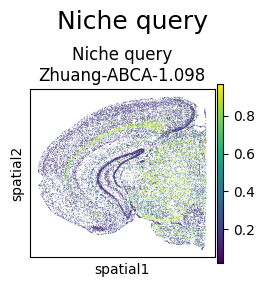

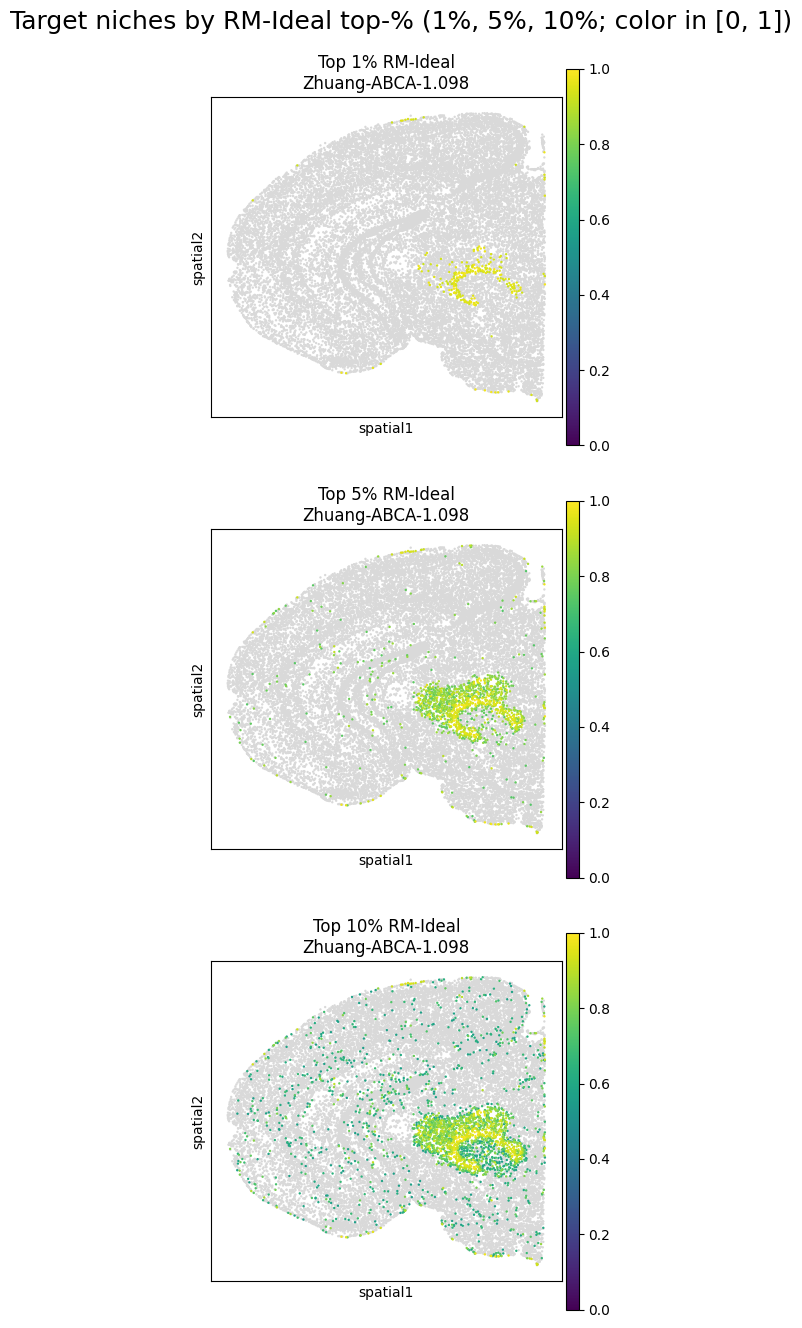

In [5]:
# step 4: run niche query on given samples

niche_query.niche_query_visualization(query_samples, show_target_niches=True, rm_target_top_pct=[1, 5, 10])

In [5]:
# step 4: classification report
niche_query.niche_query_quantitive_metrics(search_samples=query_samples, \
    result_txt_path='notebook/ccf/data/benchmark_samples/20260414_235933/quantitive_metrics/multi_parcellations_raw_gene_expression.txt')

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:AUPRC is nan: y_true is not strict binary {{0, 1}} with both classes present (n_unique=16081). AUPRC needs binary labels, e.g. target_parcellation_mask; continuous rm_ideal_score will not produce AUPRC.
INFO:src.NicheQueryPrototype.niche:Benchmark metrics (1 samples) [total]: AUPRC=nan, PCC=0.1927, Pearson=0.1927, Spearman=0.1454, MAE=0.2035, RMSE=0.2965, avg_NCJS=0.4738, AvgBIO=0.0249, AvgBATCH=nan
INFO:src.NicheQueryPrototype.niche:Pearson r (niche_query vs rm_ideal, pooled): 0.1927 (nan if no rm_ideal_score)
INFO:src.NicheQueryPrototype.niche:NDCG@K (niche_query vs rm_ideal, pooled): @1%=0.4027, @5%=0.3859, @10%=0.4038 (K=ceil(frac·n_cells) per slice; nan if no rm_ideal_score)
INFO:src.NicheQueryPrototype.niche:Overlap@Q (proxy top-K, pooled): @1%=0.0453, @5%=0.1555, @10%=0

[{'sample_id': 'Zhuang-ABCA-1.098',
  'auprc': nan,
  'pcc': 0.19268489061144456,
  'pearson': 0.19268489061144453,
  'spearman': 0.14540656388178763,
  'mae': 0.2034851881702536,
  'rmse': 0.2964844170275826,
  'avg_ncjs': 0.4737711607634557,
  'avg_bio': 0.024862795066900163,
  'avg_batch': nan,
  'ndcg_at_1pct': 0.4027151709389385,
  'ndcg_at_5pct': 0.3859131770421471,
  'ndcg_at_10pct': 0.4038250278108286,
  'overlap_at_1pct': 0.045283018867924525,
  'overlap_at_5pct': 0.15547169811320755,
  'overlap_at_10pct': 0.21442053605134012}]